In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import scipy
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

plt.rcParams['svg.fonttype'] = 'none'

In [2]:
dcd_files = os.listdir("decoded")

In [3]:
dcd_files_no_neg_ctrl = np.sort([fname for fname in dcd_files if "no_neg_ctrl" in fname and "dr0" in fname and "lf7" in fname and "cell" in fname])

In [4]:
dcd_files_neg_ctrl =np.sort([fname for fname in dcd_files if "no_neg_ctrl" not in fname and "dr0" in fname and "lf7" in fname and "cell" in fname])

In [5]:
sr = 100* (1/103)
sr

0.9708737864077669

In [6]:
nc = np.zeros(100)
ge = np.zeros(100)

#for fname in dcd_files_neg_ctrl:
for i in range(len(dcd_files_neg_ctrl)):
    fname_neg_ctrl = dcd_files_neg_ctrl[i]
    fname_no_neg_ctrl = dcd_files_no_neg_ctrl[i]
    assert(fname_neg_ctrl[-44:] == fname_no_neg_ctrl[-44:])

    dcd_neg_ctrl = pd.read_csv("decoded/" + fname_neg_ctrl)
    dcd_no_neg_ctrl = pd.read_csv("decoded/" + fname_no_neg_ctrl)
    
    gene_coords_neg_ctrl = dcd_neg_ctrl.loc[dcd_neg_ctrl.gene == "negative_control", ["gene", "x", "y"]]
    gene_coords_no_neg_ctrl = dcd_no_neg_ctrl.loc[:, ["gene", "x", "y"]]
    
    tree = scipy.spatial.KDTree(gene_coords_no_neg_ctrl.loc[:,["x","y"]])
    
    nbrs_ge = tree.query_ball_point(gene_coords_no_neg_ctrl.loc[:,["x","y"]],sr)
    nbrs_nc = tree.query_ball_point(gene_coords_neg_ctrl.loc[:,["x","y"]],sr)

    gene_coords_no_neg_ctrl["nnbrs"] = [len(n) for n in nbrs_ge]
    gene_coords_neg_ctrl["nnbrs"] = [len(n) for n in nbrs_nc]
    
    gene_coords_ge_sort_nnbrs = gene_coords_no_neg_ctrl.sort_values("nnbrs")
    gene_coords_nc_sort_nnbrs = gene_coords_neg_ctrl.sort_values("nnbrs")

    nnbrs_by_radius_ge = gene_coords_ge_sort_nnbrs.groupby("nnbrs").size()
    nnbrs_by_radius_nc = gene_coords_nc_sort_nnbrs.groupby("nnbrs").size()

    ge_nc_r = pd.DataFrame({"gen": nnbrs_by_radius_ge})
    ge_nc_r["nc"] = nnbrs_by_radius_nc
    ge_nc_r = ge_nc_r.fillna(0)

    for nnbrs, row in ge_nc_r.iterrows():
        nc[nnbrs] += row["nc"]
        ge[nnbrs] += row["gen"]


In [7]:
gen_nc_r_all_100nm = pd.DataFrame({"gen": ge, "nc" : nc})

In [8]:
gen_nc_r_all_100nm.loc[:10]

,gen,nc
0,0.0,0.0
1,1466168.0,129765.0
2,560364.0,65214.0
3,121546.0,20932.0
4,18945.0,4880.0
5,2377.0,961.0
6,334.0,182.0
7,75.0,51.0
8,18.0,17.0
9,9.0,6.0


In [9]:
# text reported number: proportion of barcodes within 
np.sum(gen_nc_r_all_100nm.loc[2:, "gen"])/np.sum(gen_nc_r_all_100nm.loc[:, "gen"])

np.float64(0.32429578811680326)

In [10]:
est_fdr_100nm = (gen_nc_r_all_100nm.nc * 271)/(2100 - 271) / gen_nc_r_all_100nm.gen

In [11]:
est_fdr_100nm.loc[1:7]


1    0.013114
2    0.017244
3    0.025517
4    0.038166
5    0.059903
6    0.080738
7    0.100755
dtype: float64

Estimate Error bars with bootstrap

In [12]:
eu = []
el = []
reps = 10000
for i in range(1,8):
    inc = gen_nc_r_all_100nm.loc[i, "nc"]
    igen = gen_nc_r_all_100nm.loc[i, "gen"]
    ibc = inc+igen
    p = inc/ibc
    nc_bs = np.random.binomial(ibc, p, reps)
    fdr_bs = (nc_bs * 271)/(2100 - 271) / (ibc-nc_bs)
    fdr_bs.sort()
    el.append(fdr_bs[249])
    eu.append(fdr_bs[9749])
    

In [13]:
error_lower = est_fdr_100nm.loc[1:7] - np.array(el)
error_upper = np.array(eu) - est_fdr_100nm.loc[1:7]

In [15]:
dcd_files_rep1 = os.listdir("seqFISHplus2019_results/rep1")
dcd_files_rep2 = os.listdir("seqFISHplus2019_results/rep2")

dcd_files_rep1_no_neg_ctrl = np.sort([fname for fname in dcd_files_rep1 if "no_neg_ctrl" in fname and "wf4.0" in fname and "lf10.5" in fname and "cell" in fname])
dcd_files_rep1_w_neg_ctrl = np.sort([fname for fname in dcd_files_rep1 if "w_neg_ctrl" in fname and "wf4.0" in fname and "lf10.5" in fname and "cell" in fname])

dcd_files_rep2_no_neg_ctrl = np.sort([fname for fname in dcd_files_rep2 if "no_neg_ctrl" in fname and "wf4.0" in fname and "lf10.5" in fname and "cell" in fname])
dcd_files_rep2_w_neg_ctrl = np.sort([fname for fname in dcd_files_rep2 if "w_neg_ctrl" in fname and "wf4.0" in fname and "lf10.5" in fname and "cell" in fname])

In [16]:
len(dcd_files_rep2_no_neg_ctrl) == len(dcd_files_rep2_w_neg_ctrl)

True

In [17]:
nc = np.zeros(100)
ge = np.zeros(100)

sr = 100* (1/103)
sr

#for fname in dcd_files_neg_ctrl:
for i in range(len(dcd_files_rep2_w_neg_ctrl)):
    fname_neg_ctrl = dcd_files_rep2_w_neg_ctrl[i]
    fname_no_neg_ctrl = dcd_files_rep2_no_neg_ctrl[i]
    assert(fname_neg_ctrl[-44:] == fname_no_neg_ctrl[-44:])

    dcd_neg_ctrl = pd.read_csv("seqFISHplus2019_results/rep2/" + fname_neg_ctrl)
    dcd_no_neg_ctrl = pd.read_csv("seqFISHplus2019_results/rep2/" + fname_no_neg_ctrl)
    
    gene_coords_neg_ctrl = dcd_neg_ctrl.loc[dcd_neg_ctrl.gene == "negative_control", ["gene", "x", "y"]]
    gene_coords_no_neg_ctrl = dcd_no_neg_ctrl.loc[:, ["gene", "x", "y"]]
    
    tree = scipy.spatial.KDTree(gene_coords_no_neg_ctrl.loc[:,["x","y"]])
    
    nbrs_ge = tree.query_ball_point(gene_coords_no_neg_ctrl.loc[:,["x","y"]],sr)
    nbrs_nc = tree.query_ball_point(gene_coords_neg_ctrl.loc[:,["x","y"]],sr)

    gene_coords_no_neg_ctrl["nnbrs"] = [len(n) for n in nbrs_ge]
    gene_coords_neg_ctrl["nnbrs"] = [len(n) for n in nbrs_nc]
    
    gene_coords_ge_sort_nnbrs = gene_coords_no_neg_ctrl.sort_values("nnbrs")
    gene_coords_nc_sort_nnbrs = gene_coords_neg_ctrl.sort_values("nnbrs")

    nnbrs_by_radius_ge = gene_coords_ge_sort_nnbrs.groupby("nnbrs").size()
    nnbrs_by_radius_nc = gene_coords_nc_sort_nnbrs.groupby("nnbrs").size()

    ge_nc_r = pd.DataFrame({"gen": nnbrs_by_radius_ge})
    ge_nc_r["nc"] = nnbrs_by_radius_nc
    ge_nc_r = ge_nc_r.fillna(0)

    for nnbrs, row in ge_nc_r.iterrows():
        nc[nnbrs] += row["nc"]
        ge[nnbrs] += row["gen"]


In [18]:
#nc1 = np.zeros(100)
#ge1 = np.zeros(100)

sr = 100* (1/103)
sr

#for fname in dcd_files_neg_ctrl:
for i in range(len(dcd_files_rep1_w_neg_ctrl)):
    fname_neg_ctrl = dcd_files_rep1_w_neg_ctrl[i]
    fname_no_neg_ctrl = dcd_files_rep1_no_neg_ctrl[i]
    assert(fname_neg_ctrl[-44:] == fname_no_neg_ctrl[-44:])

    dcd_neg_ctrl = pd.read_csv("seqFISHplus2019_results/rep1/" + fname_neg_ctrl)
    dcd_no_neg_ctrl = pd.read_csv("seqFISHplus2019_results/rep1/" + fname_no_neg_ctrl)
    
    gene_coords_neg_ctrl = dcd_neg_ctrl.loc[dcd_neg_ctrl.gene == "negative_control", ["gene", "x", "y"]]
    gene_coords_no_neg_ctrl = dcd_no_neg_ctrl.loc[:, ["gene", "x", "y"]]
    
    tree = scipy.spatial.KDTree(gene_coords_no_neg_ctrl.loc[:,["x","y"]])
    
    nbrs_ge = tree.query_ball_point(gene_coords_no_neg_ctrl.loc[:,["x","y"]],sr)
    nbrs_nc = tree.query_ball_point(gene_coords_neg_ctrl.loc[:,["x","y"]],sr)

    gene_coords_no_neg_ctrl["nnbrs"] = [len(n) for n in nbrs_ge]
    gene_coords_neg_ctrl["nnbrs"] = [len(n) for n in nbrs_nc]
    
    gene_coords_ge_sort_nnbrs = gene_coords_no_neg_ctrl.sort_values("nnbrs")
    gene_coords_nc_sort_nnbrs = gene_coords_neg_ctrl.sort_values("nnbrs")

    nnbrs_by_radius_ge = gene_coords_ge_sort_nnbrs.groupby("nnbrs").size()
    nnbrs_by_radius_nc = gene_coords_nc_sort_nnbrs.groupby("nnbrs").size()

    ge_nc_r = pd.DataFrame({"gen": nnbrs_by_radius_ge})
    ge_nc_r["nc"] = nnbrs_by_radius_nc
    ge_nc_r = ge_nc_r.fillna(0)

    for nnbrs, row in ge_nc_r.iterrows():
        nc[nnbrs] += row["nc"]
        ge[nnbrs] += row["gen"]


In [19]:
gen_nc_r_sfp_100nm = pd.DataFrame({"gen": ge, "nc" : nc})
est_fdr_sfp_100nm = (gen_nc_r_sfp_100nm.nc * 10000)/(14000) / gen_nc_r_sfp_100nm.gen

In [20]:
gen_nc_r_sfp_100nm.iloc[:20, :]

,gen,nc
0,0.0,0.0
1,4515118.0,161699.0
2,1365608.0,69482.0
3,234687.0,20631.0
4,34379.0,6626.0
5,8054.0,3243.0
6,4070.0,2144.0
7,2844.0,1581.0
8,2234.0,1145.0
9,1566.0,914.0


In [21]:
0.39/(1-0.27)

0.5342465753424658

In [22]:
np.sum(gen_nc_r_sfp_100nm.loc[2:, "gen"])/np.sum(gen_nc_r_sfp_100nm.loc[:, "gen"])

np.float64(0.2684524601308909)

In [23]:
eu_sfp = []
el_sfp = []
reps = 10000
for i in range(1,8):
    inc = gen_nc_r_sfp_100nm.loc[i, "nc"]
    igen = gen_nc_r_sfp_100nm.loc[i, "gen"]
    ibc = inc+igen
    p = inc/ibc
    nc_bs = np.random.binomial(ibc, p, reps)
    fdr_bs = (nc_bs * 10000)/(14000) / (ibc-nc_bs)
    fdr_bs.sort()
    el_sfp.append(fdr_bs[249])
    eu_sfp.append(fdr_bs[9749])
    

In [24]:
error_lower_sfp = est_fdr_sfp_100nm.loc[1:7] - np.array(el_sfp)
error_upper_sfp = np.array(eu_sfp) - est_fdr_sfp_100nm.loc[1:7]

In [26]:
mouse_curve = pd.read_csv("mouse_cortex_dens_eFDR_plot_lvf7.csv")

In [27]:
mouse_curve

,Unnamed: 0,est_fdr_100nm,error_lower,error_upper
0,1,0.013879,0.000070,0.000069
1,2,0.024613,0.000208,0.000207
2,3,0.056808,0.000884,0.000895
3,4,0.133645,0.003776,0.003766
4,5,0.179441,0.007275,0.007698
5,6,0.190510,0.009256,0.009658
6,7,0.179748,0.010263,0.011314


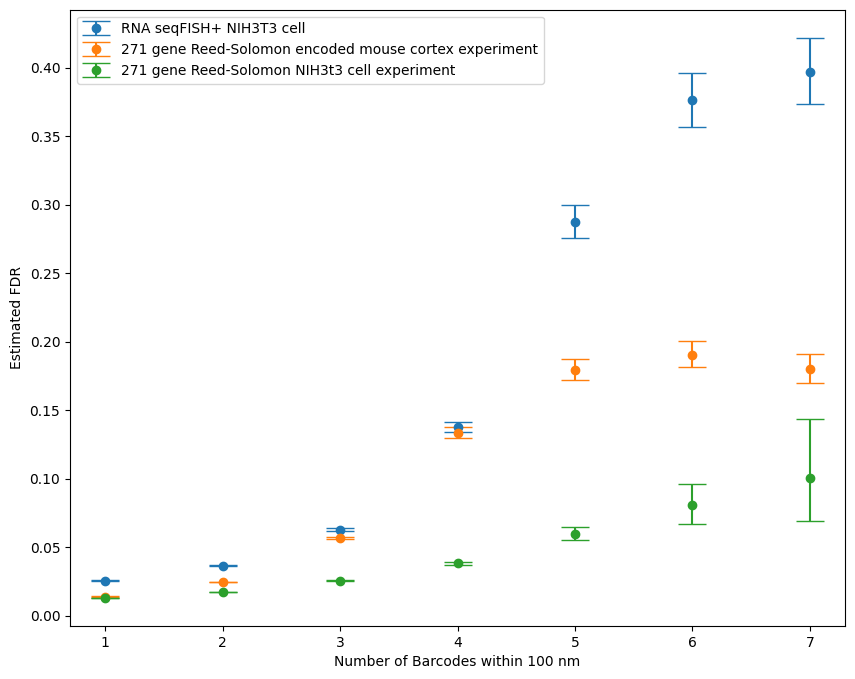

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(10,8))
ax.errorbar(range(1,8), est_fdr_sfp_100nm.loc[1:7], yerr = np.array([error_lower_sfp, error_upper_sfp]), fmt="o",capsize=10, label="RNA seqFISH+ NIH3T3 cell")
ax.errorbar(range(1,8), mouse_curve["est_fdr_100nm"], yerr = np.array([mouse_curve['error_lower'], mouse_curve['error_upper']]), fmt="o",capsize=10, label="271 gene Reed-Solomon encoded mouse cortex experiment")
ax.errorbar(range(1,8), est_fdr_100nm.loc[1:7], yerr = np.array([error_lower, error_upper]), fmt="o",capsize=10, label="271 gene Reed-Solomon NIH3t3 cell experiment")

ax.set_xlabel("Number of Barcodes within 100 nm")
ax.set_ylabel("Estimated FDR")
plt.legend()
fig.savefig('fig2D.pdf')